In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,silhouette_samples

In [0]:
spotify_user_behavior = spark.table(
    "spotify.spotify_user_behavior"
).toPandas()

In [0]:
CLUSTER_FEATURES_V1 = [
    "daily_listening_minutes", #usage intensity
    "sessions_per_day",        #frequency
    "days_active_last_30",     #consistencyspotify_user_behavior = spark.table(
    "avg_session_minutes",     #depth
    "skip_rate",               #content friction
    "liked_songs_pct",         #positive engagement
    "ads_skipped_pct",         #monetization friction
]

In [0]:
base = spotify_user_behavior[["user_id"] + CLUSTER_FEATURES_V1].copy()
before_rows = len(base)
base = base.dropna(subset=CLUSTER_FEATURES_V1)
after_rows = len(base)

if before_rows!= after_rows:
    print(f"dropped {before_rows-after_rows} rows due to nulls")

K=4
X1 = base[CLUSTER_FEATURES_V1].copy()
km1= KMeans (
    n_clusters= K,
    random_state=42,
    n_init=20,
    max_iter = 300
)

In [0]:
labels1 = km1.fit_predict(X1)
inertia1 = km1.inertia_
sill_avg_1 = silhouette_score(X1, labels1)
print("\nIteration 1 Results")
print("Silhouette Avg:" ,round(sill_avg_1,3))
print("Inertia:",round(inertia1,2))


Iteration 1 Results
Silhouette Avg: 0.515
Inertia: 53703427.73


In [0]:
base_iter1 = base.copy()
base_iter1["cluster"] = labels1
sizes1 = base_iter1["cluster"].value_counts().sort_index()
means1 = (
    base_iter1.groupby("cluster")[CLUSTER_FEATURES_V1]
    .mean()
    .round(3)
)

In [0]:
profile1 = means1.copy()
profile1.insert(0,"cluster_size",sizes1)
display(profile1)

cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
64364,19.856434853443687,1.141,20.711689530042907,18.354081362562315,0.351,0.2744512332066867,0.5173755690419698
11069,107.96818663461094,1.742,22.183715219449827,77.59498633456487,0.287,0.3036627994667376,0.5998217329265335
1903,229.9233986688061,3.869,23.02739336393134,80.98213577608956,0.284,0.3178919587448702,0.5776118309132263
30664,53.237406679166924,1.342,21.656940217144875,44.33973725715372,0.289,0.30257552562529083,0.5769627874496115


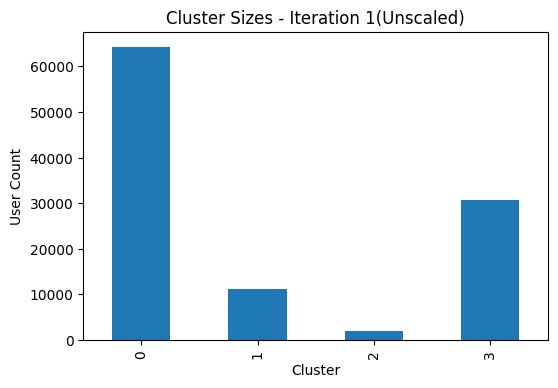

In [0]:
plt.figure(figsize=(6,4))
base_iter1["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Sizes - Iteration 1(Unscaled)")
plt.xlabel("Cluster")
plt.ylabel("User Count")
plt.show()




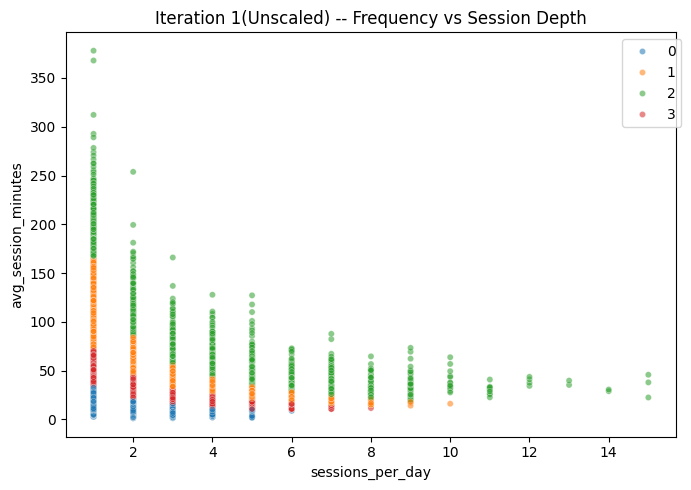

In [0]:
#frequency vs Session depth
plt.figure(figsize=(7,5))
sns.scatterplot(
    data= base_iter1,
    x="sessions_per_day",
    y="avg_session_minutes",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
)
plt.title("Iteration 1(Unscaled) -- Frequency vs Session Depth")
plt.legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

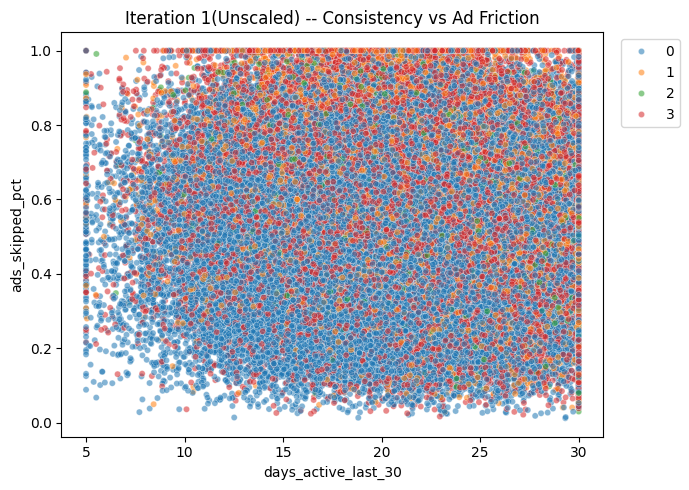

In [0]:
#Consisitency vs Ad Friction
plt.figure(figsize=(7,5))
sns.scatterplot(
    data= base_iter1,
    x="days_active_last_30",
    y="ads_skipped_pct",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
)
plt.title("Iteration 1(Unscaled) -- Consistency vs Ad Friction")
plt.legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

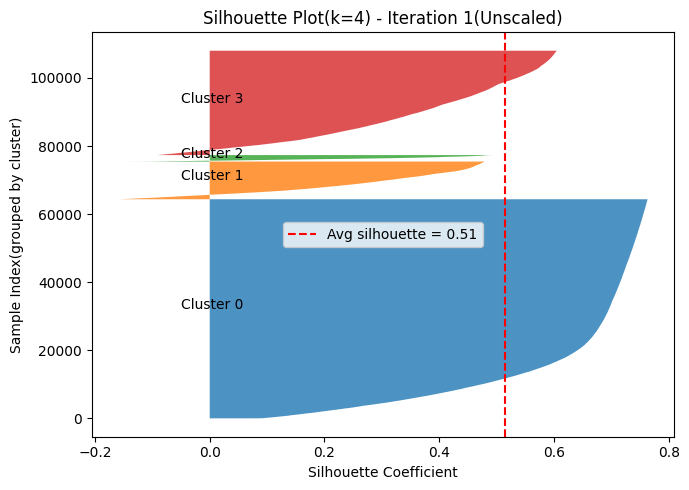

Iteration 1 Avg Silhouette 0.515


In [0]:
# Silhouette Plot
sil_values_1 = silhouette_samples(X1, labels1)
sill_avg_1 = silhouette_score(X1, labels1)
plt.figure(figsize=(7,5))
y_lower = 0


vals0 = sil_values_1[labels1 == 0]
vals0.sort()
size0 = vals0.shape[0]
y_upper = y_lower + size0
plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals0,
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5*size0,
    "Cluster 0 "
)
y_lower = y_upper 


vals1 = sil_values_1[labels1 == 1]
vals1.sort()
size1 = vals1.shape[0]
y_upper = y_lower + size1
plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals1,
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5*size1,
    "Cluster 1 "
)
y_lower = y_upper 


vals2 = sil_values_1[labels1 == 2]
vals2.sort()
size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals2,
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5*size2,
    "Cluster 2 "
)
y_lower = y_upper 


vals3 = sil_values_1[labels1 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals3,
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5*size3,
    "Cluster 3 "
)
y_lower = y_upper 


plt.axvline(
    x=sill_avg_1,
    color="red",
    linestyle="--",
    label = f"Avg silhouette = {sill_avg_1:.2f}"
)
plt.title("Silhouette Plot(k=4) - Iteration 1(Unscaled)")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Sample Index(grouped by cluster)")
plt.legend()
plt.tight_layout()
plt.show()

print("Iteration 1 Avg Silhouette", round(sill_avg_1,3))